In [396]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [397]:
df=pd.read_csv('house_linear.csv')

In [398]:
df.head()

,area,bedrooms,age,town,price
0,2122.0,4.0,28.0,monroe township,554200
1,NaN,2.0,4.0,princeton,792500
2,2680.0,4.0,47.0,west windsor,659800
3,3223.0,5.0,20.0,princeton,866900
4,2761.0,5.0,17.0,edison,753400


# Part A — Data Understanding + Preprocessing

In [399]:
df.head()

,area,bedrooms,age,town,price
0,2122.0,4.0,28.0,monroe township,554200
1,NaN,2.0,4.0,princeton,792500
2,2680.0,4.0,47.0,west windsor,659800
3,3223.0,5.0,20.0,princeton,866900
4,2761.0,5.0,17.0,edison,753400


In [400]:
df.shape

(180, 5)

In [401]:
df.dtypes

,0
area,float64
bedrooms,float64
age,float64
town,object
price,int64


In [402]:
df.isnull().sum()

,0
area,8
bedrooms,7
age,6
town,9
price,0


In [403]:
df['age'].fillna(df['age'].median(),inplace=True)

/tmp/ipykernel_333/2790788646.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)


In [404]:
df.isnull().sum()

,0
area,8
bedrooms,7
age,0
town,9
price,0


In [405]:
df['town'].fillna('Unknown',inplace=True)

/tmp/ipykernel_333/1640332106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['town'].fillna('Unknown',inplace=True)


In [406]:
df['area'].fillna(df['area'].median(),inplace=True)

/tmp/ipykernel_333/1145505224.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['area'].fillna(df['area'].median(),inplace=True)


In [407]:
df['bedrooms'].fillna(df['bedrooms'].median(),inplace=True)

/tmp/ipykernel_333/2997329818.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bedrooms'].fillna(df['bedrooms'].median(),inplace=True)


In [408]:
df.isnull().sum()

,0
area,0
bedrooms,0
age,0
town,0
price,0


In [409]:
df['town'].value_counts()

,count
town,
monroe township,43
west windsor,42
princeton,40
robinsville,24
edison,22
Unknown,9


In [410]:
df_encoded = pd.get_dummies(df, columns=['town'],dtype=int)

In [411]:
df_encoded

,area,bedrooms,age,price,town_Unknown,town_edison,town_monroe township,town_princeton,town_robinsville,town_west windsor
0,2122.0,4.0,28.0,554200,0,0,1,0,0,0
1,2959.5,2.0,4.0,792500,0,0,0,1,0,0
2,2680.0,4.0,47.0,659800,0,0,0,0,0,1
3,3223.0,5.0,20.0,866900,0,0,0,1,0,0
4,2761.0,5.0,17.0,753400,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
175,3139.0,3.0,4.0,771600,0,0,1,0,0,0
176,2611.0,4.0,5.0,692500,0,0,0,0,0,1
177,2723.0,5.0,28.0,693300,0,0,0,0,0,1
178,4287.0,3.0,36.0,983900,0,0,1,0,0,0


In [412]:
x=df_encoded.drop('price',axis=1)
y=df_encoded['price']

In [413]:
x.shape

(180, 9)

In [414]:
y.shape

(180,)

In [415]:
y.dtype

dtype('int64')

In [416]:
df_1 = df.replace(to_replace=[-99999,-88888,'NA','?'], value=np.nan)

# Part B — Statistics + Visualization

In [417]:
df['area'].median()

2959.5

In [418]:
df['area'].mean()

np.float64(-451.1388888888889)

In [419]:
df['area'].std()

18541.766769838374

In [420]:
df.describe()

,area,bedrooms,age,price
count,180.000000,180.000000,180.00000,1.800000e+02
mean,-451.138889,3.361111,-2752.95000,7.339610e+05
std,18541.766770,0.920067,16483.44028,1.080901e+05
min,-99999.000000,2.000000,-99999.00000,4.641000e+05
25%,2672.250000,3.000000,12.75000,6.708250e+05
50%,2959.500000,3.000000,24.00000,7.250000e+05
75%,3283.750000,4.000000,36.00000,7.884500e+05
max,4287.000000,5.000000,54.00000,1.276771e+06


In [421]:
a = df['age']

Q1 = np.percentile(a, 25)
Q3 = np.percentile(a, 75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
print(Q1)

print(Q3)

print(IQR)
print("Lower Limit:", lower_iqr)
print("Upper Limit:", upper_iqr)

12.75
36.0
23.25
Lower Limit: -22.125
Upper Limit: 70.875


In [422]:
outliers = df[(df['age'] < lower_iqr) | (df['age'] > upper_iqr)]
print(outliers)

       area  bedrooms      age             town   price
9    2629.0       5.0 -99999.0      robinsville  679300
62   2242.0       5.0 -99999.0  monroe township  672400
80   2912.0       4.0 -99999.0  monroe township  721500
127  3028.0       5.0 -99999.0        princeton  774600
159  3004.0       4.0 -99999.0  monroe township  673900


In [423]:
df2 = df[(df['age'] >= lower_iqr) & (df['age'] <= upper_iqr)]

In [424]:
df2

,area,bedrooms,age,town,price
0,2122.0,4.0,28.0,monroe township,554200
1,2959.5,2.0,4.0,princeton,792500
2,2680.0,4.0,47.0,west windsor,659800
3,3223.0,5.0,20.0,princeton,866900
4,2761.0,5.0,17.0,edison,753400
...,...,...,...,...,...
175,3139.0,3.0,4.0,monroe township,771600
176,2611.0,4.0,5.0,west windsor,692500
177,2723.0,5.0,28.0,west windsor,693300
178,4287.0,3.0,36.0,monroe township,983900


In [425]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [426]:
# Mean
mean_area = df['area'].mean()
mean_price = df['price'].mean()

# Median
median_area = df['area'].median()
median_price = df['price'].median()

# Standard Deviation
std_area = df['area'].std()
std_price = df['price'].std()

In [427]:
# Area
Q1_area = df['area'].quantile(0.25)
Q3_area = df['area'].quantile(0.75)
IQR_area = Q3_area - Q1_area

# Price
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

In [428]:
print("AREA")
print("Mean:", mean_area)
print("Median:", median_area)
print("Std:", std_area)
print("Q1:", Q1_area)
print("Q3:", Q3_area)
print("IQR:", IQR_area)

print("\nPRICE")
print("Mean:", mean_price)
print("Median:", median_price)
print("Std:", std_price)
print("Q1:", Q1_price)
print("Q3:", Q3_price)
print("IQR:", IQR_price)

AREA
Mean: -451.1388888888889
Median: 2959.5
Std: 18541.766769838374
Q1: 2672.25
Q3: 3283.75
IQR: 611.5

PRICE
Mean: 733960.9722222222
Median: 725000.0
Std: 108090.09133831078
Q1: 670825.0
Q3: 788450.0
IQR: 117625.0


In [429]:
mean_price = df['price'].mean()
std_price = df['price'].std()

lower_3sigma = mean_price - 3 * std_price
upper_3sigma = mean_price + 3 * std_price

In [430]:
outliers = df[(df['price'] < lower_3sigma) | (df['price'] > upper_3sigma)]

In [431]:
print("Number of outliers:", len(outliers))
print("Outlier row indices:")
print(outliers.index.tolist())

print("Outlier price values:")
print(outliers['price'].values)

Number of outliers: 2
Outlier row indices:
[17, 126]
Outlier price values:
[1270322 1276771]


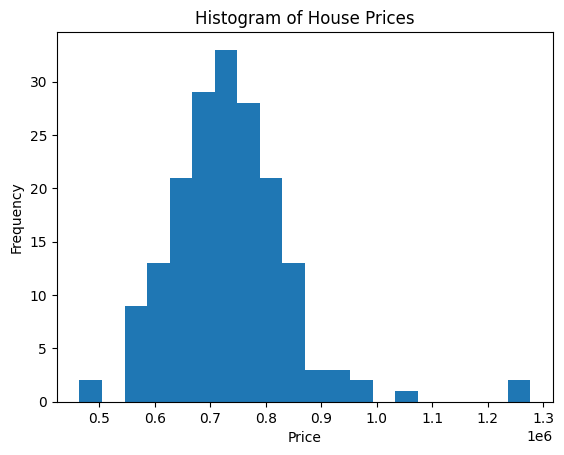

In [432]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['price'], bins=20)
plt.title("Histogram of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

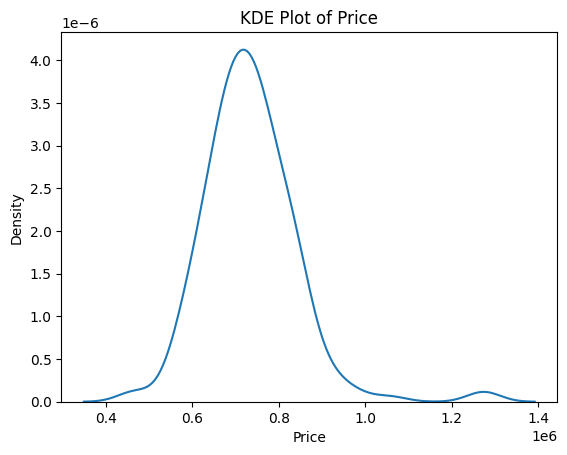

In [433]:
plt.figure()
sns.kdeplot(df['price'])
plt.title("KDE Plot of Price")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

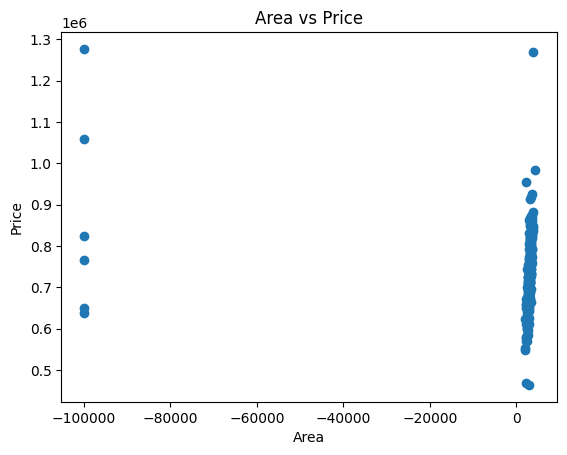

In [434]:
plt.figure()
plt.scatter(df['area'], df['price'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

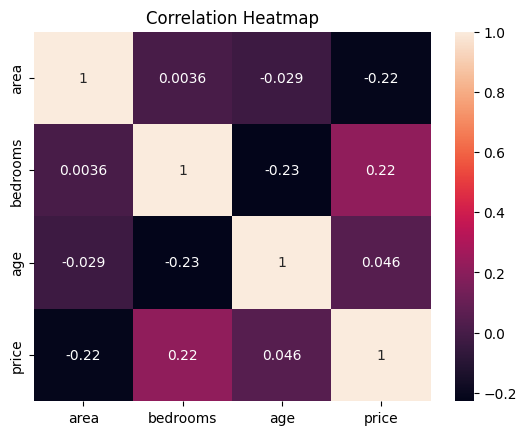

In [435]:
plt.figure()
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Part C — Machine Learning Model

In [436]:
x.head()

,area,bedrooms,age,town_Unknown,town_edison,town_monroe township,town_princeton,town_robinsville,town_west windsor
0,2122.0,4.0,28.0,0,0,1,0,0,0
1,2959.5,2.0,4.0,0,0,0,1,0,0
2,2680.0,4.0,47.0,0,0,0,0,0,1
3,3223.0,5.0,20.0,0,0,0,1,0,0
4,2761.0,5.0,17.0,0,1,0,0,0,0


In [437]:
y.head()

,price
0,554200
1,792500
2,659800
3,866900
4,753400


In [438]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [439]:
# X = numeric features only
numeric_cols = x.select_dtypes(include=['number']).columns
scaler = MinMaxScaler()
X_scaled = x.copy()
X_scaled[numeric_cols] = scaler.fit_transform(x[numeric_cols])


In [440]:
X_scaled

,area,bedrooms,age,town_Unknown,town_edison,town_monroe township,town_princeton,town_robinsville,town_west windsor
0,0.979240,0.666667,0.99974,0.0,0.0,1.0,0.0,0.0,0.0
1,0.987271,0.000000,0.99950,0.0,0.0,0.0,1.0,0.0,0.0
2,0.984590,0.666667,0.99993,0.0,0.0,0.0,0.0,0.0,1.0
3,0.989797,1.000000,0.99966,0.0,0.0,0.0,1.0,0.0,0.0
4,0.985367,1.000000,0.99963,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
175,0.988992,0.333333,0.99950,0.0,0.0,1.0,0.0,0.0,0.0
176,0.983929,0.666667,0.99951,0.0,0.0,0.0,0.0,0.0,1.0
177,0.985003,1.000000,0.99974,0.0,0.0,0.0,0.0,0.0,1.0
178,1.000000,0.333333,0.99982,0.0,0.0,1.0,0.0,0.0,0.0


In [441]:
x.head()

,area,bedrooms,age,town_Unknown,town_edison,town_monroe township,town_princeton,town_robinsville,town_west windsor
0,2122.0,4.0,28.0,0,0,1,0,0,0
1,2959.5,2.0,4.0,0,0,0,1,0,0
2,2680.0,4.0,47.0,0,0,0,0,0,1
3,3223.0,5.0,20.0,0,0,0,1,0,0
4,2761.0,5.0,17.0,0,1,0,0,0,0


In [442]:
from sklearn.model_selection import train_test_split

In [443]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [444]:
x_train.head()

,area,bedrooms,age,town_Unknown,town_edison,town_monroe township,town_princeton,town_robinsville,town_west windsor
117,0.991869,0.000000,0.99963,0.0,0.0,1.0,0.0,0.0,0.0
65,0.981858,0.333333,0.99988,0.0,0.0,1.0,0.0,0.0,0.0
67,0.991063,0.333333,0.99970,0.0,1.0,0.0,0.0,0.0,0.0
31,0.984159,0.666667,0.99988,0.0,0.0,0.0,0.0,1.0,0.0
12,0.987726,0.333333,0.99963,0.0,0.0,0.0,0.0,0.0,1.0


In [445]:
y_train.head()

,price
117,782400
65,570500
67,758500
31,584200
12,721400


In [446]:
x_test.shape

(36, 9)

In [447]:
x_train.shape

(144, 9)

In [448]:
y_train.shape

(144,)

In [449]:
from sklearn.linear_model import LinearRegression

In [450]:
lr=LinearRegression()

In [451]:
reg=lr.fit(x_train,y_train)

In [452]:
pred=reg.predict(x_test)

In [453]:
from sklearn.metrics import r2_score

In [454]:
acc=r2_score(y_test,pred)

In [455]:
acc

0.12243260440309389

In [456]:
pred

array([675816.40748922, 756229.91326706, 720033.29097899, 767671.7988101 ,
       703020.063324  , 701783.42943112, 701376.54469891, 803875.07359098,
       687648.64007285, 756317.40210439, 701866.94498826, 686981.24990233,
       687420.48695788, 703097.66667194, 782946.0032912 , 702755.20112569,
       746789.50958268, 675892.52122892, 810121.99822175, 730401.36563487,
       755967.32730156, 702980.53623952, 747456.69363641, 703210.14315012,
       698775.53757446, 701888.68922135, 674565.52672006, 729069.27243014,
       702870.54045866, 703229.60668848, 774150.78416005, 730140.06778772,
       660617.9693234 , 735245.53715272, 755842.32455799, 746896.58884842])

In [457]:
y_test

,price
19,745000
42,735000
153,651700
78,637600
145,699900
15,705000
24,836100
68,825000
113,657000
118,717600


In [458]:
print("Intercept (bias):", reg.intercept_)
print("Coefficients (weights):")
for col, coef in zip(x_train.columns, reg.coef_):
    print(col, ":", coef)

Intercept (bias): 695746.4388566975
Coefficients (weights):
area : -48253.81497405839
bedrooms : 81006.5443764044
age : 43009.638273114426
town_Unknown : -5122.02439634676
town_edison : -16333.5376505387
town_monroe township : -15109.38939788549
town_princeton : 38121.113687895406
town_robinsville : -30490.798139722127
town_west windsor : 28934.635896598094


In [459]:
reg.coef_

array([-48253.81497406,  81006.5443764 ,  43009.63827311,  -5122.02439635,
       -16333.53765054, -15109.38939789,  38121.1136879 , -30490.79813972,
        28934.6358966 ])

In [460]:
reg.score(x_test,y_test)

0.12243260440309389

# Again

In [461]:
df

,area,bedrooms,age,town,price
0,2122.0,4.0,28.0,monroe township,554200
1,2959.5,2.0,4.0,princeton,792500
2,2680.0,4.0,47.0,west windsor,659800
3,3223.0,5.0,20.0,princeton,866900
4,2761.0,5.0,17.0,edison,753400
...,...,...,...,...,...
175,3139.0,3.0,4.0,monroe township,771600
176,2611.0,4.0,5.0,west windsor,692500
177,2723.0,5.0,28.0,west windsor,693300
178,4287.0,3.0,36.0,monroe township,983900


In [462]:
from sklearn.preprocessing import LabelEncoder

In [463]:
le=LabelEncoder()

In [464]:
df['town']=le.fit_transform(df['town'])

In [465]:
df

,area,bedrooms,age,town,price
0,2122.0,4.0,28.0,2,554200
1,2959.5,2.0,4.0,3,792500
2,2680.0,4.0,47.0,5,659800
3,3223.0,5.0,20.0,3,866900
4,2761.0,5.0,17.0,1,753400
...,...,...,...,...,...
175,3139.0,3.0,4.0,2,771600
176,2611.0,4.0,5.0,5,692500
177,2723.0,5.0,28.0,5,693300
178,4287.0,3.0,36.0,2,983900


In [466]:
x=df.drop(['price','age'],axis=1)
y=df['price']

In [467]:
x.head()

,area,bedrooms,town
0,2122.0,4.0,2
1,2959.5,2.0,3
2,2680.0,4.0,5
3,3223.0,5.0,3
4,2761.0,5.0,1


In [468]:
y.head()

,price
0,554200
1,792500
2,659800
3,866900
4,753400


In [469]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [470]:
x_train

,area,bedrooms,town
117,3439.0,2.0,2
65,2395.0,3.0,2
67,3355.0,3.0,1
31,2635.0,4.0,4
12,3007.0,3.0,5
...,...,...,...
71,2923.0,3.0,2
106,3331.0,5.0,3
14,2913.0,4.0,5
92,2943.0,2.0,2


In [471]:
y_train

,price
117,782400
65,570500
67,758500
31,584200
12,721400
...,...
71,675600
106,845200
14,805500
92,643400


In [472]:
reg2=LinearRegression()

In [473]:
reg2.fit(x_train,y_train)

LinearRegression()

In [474]:
reg2.score(x_test,y_test)

0.10920274124181317